In [1]:
'''
Code for testing a mixer module, to have an HDL implementation
'''

import numpy as np
import scipy
import matplotlib.pyplot as plt

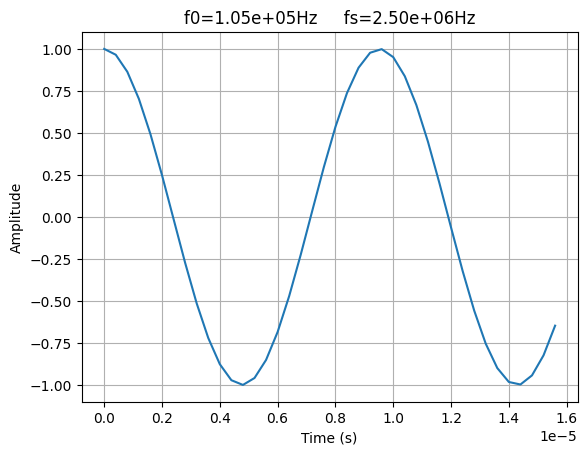

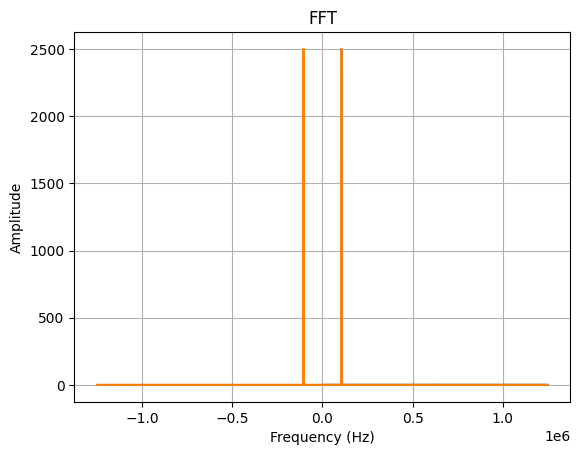

In [22]:
fs = 2_500_000       # Sample rate: 2.5 MHz
duration = 0.002      # 2 ms
f0 = 105_000          # Signal frequency: 100 kHz
flo = 100_000        # Local oscilator for mixing
amplitude = 1.0
phase = 0.0

t = np.arange(0, duration, 1 / fs)

x = amplitude * np.cos(2 * np.pi * f0 * t + phase) # Input signal

I_arr = np.cos(2 * np.pi * flo * t) # I component of local oscilator
Q_arr = np.sin(2 * np.pi * flo * t) # Q component of local oscilator

# Plotting the singal before it's mixed

plt.plot(t[:40], x[:40])
plt.title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Plot FFT of the signal

X = np.fft.rfft(x)
freq = np.fft.rfftfreq(int(duration * fs), d=1/fs)

X_shifted = np.fft.fftshift(X)
freq_shifted = np.fft.fftshift(freq)

plt.plot(freq_shifted, np.abs(X_shifted))

plt.plot(x_axis, y_axis)
plt.title("FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

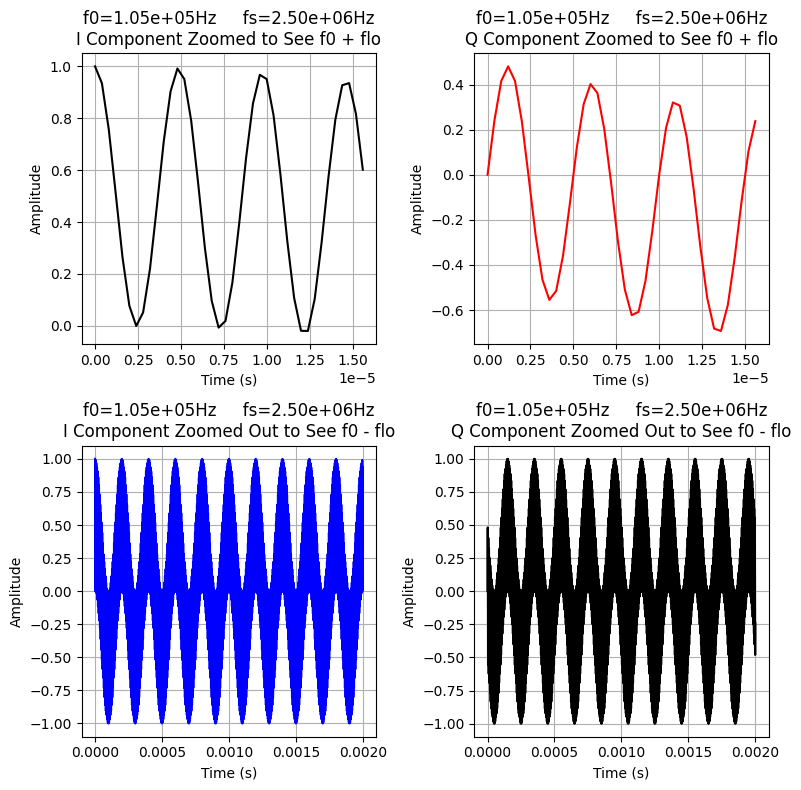

In [28]:
# Multiply the input by the local osciallator and observe the effects

I_x = I_arr * x
Q_x = Q_arr * x

# Plot the two signals

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

axs[0,0].plot(t[:40], I_x[:40], color='k')
axs[0,0].set_xlabel("Time (s)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component Zoomed to See f0 + flo")
axs[0,0].grid()

axs[0,1].plot(t[:40], Q_x[:40], color='r')
axs[0,1].set_xlabel("Time (s)")
axs[0,1].set_ylabel("Amplitude")
axs[0,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component Zoomed to See f0 + flo")
axs[0,1].grid()

axs[1,0].plot(t, I_x, color='b')
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Amplitude")
axs[1,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component Zoomed Out to See f0 - flo")
axs[1,0].grid()

axs[1,1].plot(t, Q_x, color='k')
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component Zoomed Out to See f0 - flo")
axs[1,1].grid()
plt.tight_layout()
plt.show()

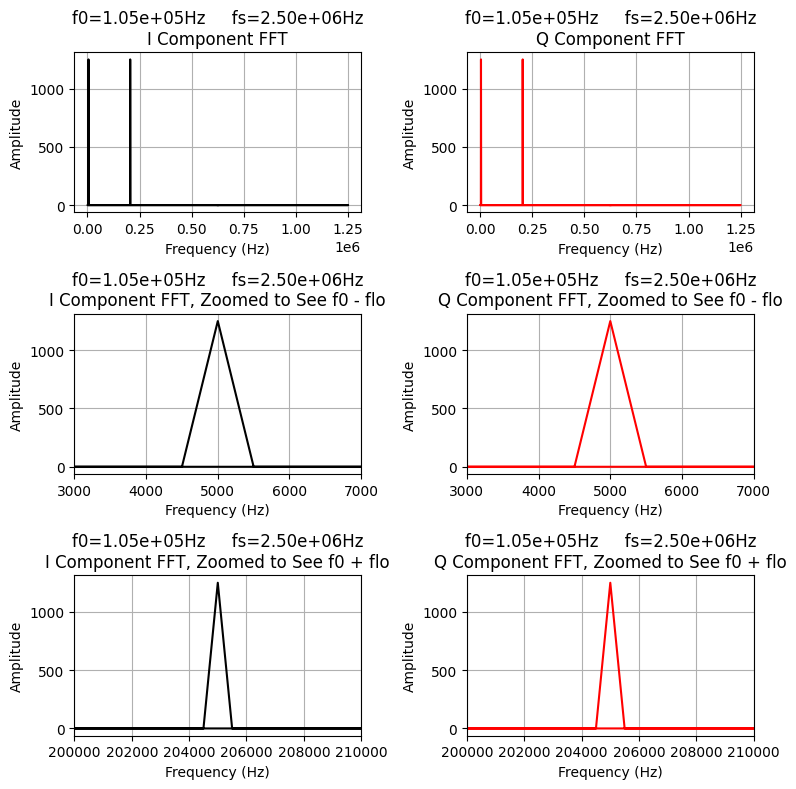

In [44]:
# Plot FFT's

I_X = np.fft.rfft(I_x)
I_X_shifted = np.fft.fftshift(I_X)
Q_X = np.fft.rfft(Q_x)
Q_X_shifted = np.fft.fftshift(Q_X)

freq = np.fft.rfftfreq(int(duration * fs), d=1/fs)
freq_shifted = np.fft.fftshift(freq)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8,8))

axs[0,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[0,0].set_xlabel("Frequency (Hz)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT")
axs[0,0].grid()

axs[0,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[0,1].set_xlabel("Frequency (Hz)")
axs[0,1].set_ylabel("Amplitude")
axs[0,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT")
axs[0,1].grid()

axs[1,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[1,0].set_xlim(3_000, 7_000)
axs[1,0].set_xlabel("Frequency (Hz)")
axs[1,0].set_ylabel("Amplitude")
axs[1,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 - flo")
axs[1,0].grid()

axs[1,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[1,1].set_xlim(3_000, 7_000)
axs[1,1].set_xlabel("Frequency (Hz)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 - flo")
axs[1,1].grid()

axs[2,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[2,0].set_xlim(200_000, 210_000)
axs[2,0].set_xlabel("Frequency (Hz)")
axs[2,0].set_ylabel("Amplitude")
axs[2,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 + flo")
axs[2,0].grid()

axs[2,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[2,1].set_xlim(200_000, 210_000)
axs[2,1].set_xlabel("Frequency (Hz)")
axs[2,1].set_ylabel("Amplitude")
axs[2,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 + flo")
axs[2,1].grid()

plt.tight_layout()
plt.show()

In [45]:
def CIC(data: np.array, in_bit: int, out_bit: int, N: int, R: int, M: int = 1, full_prec : bool = True):
    '''Important Notes:
            -Parameters: 
                -N is the number of integrator and comb stages
                -R is the decimation ratio (aka. pick every R sample).
                -M remains unused currently (may be implemented)
            -Function has a slow_clk and clk, clk repersents system clock (MHz range),
            slow_clk repersents downsampled clock.
            -...recu variables refer to recursive elements in the filter. I.e. y[n-1], x[n-1]
            for intgrator and comb respectively
            -Added redudant variables for readability and symmetry, I.e. comb_module_out. These could be removed
            for efficiency
            -Shift parameter added to toggle the bitshift due to high gain. Likely need to rethink this

            Created this function while working with LASSO
    '''
    
    if not full_prec:
        data_type = np.int64
    else:
        data_type = np.float64
    
    '''-------Useful Constants------'''
    signal_len = data.size
    output_signal_len = int(np.ceil(signal_len / R))
    
    out_rate = int(np.log2(R))
    B_growth = int(np.ceil(N * np.log2(R * M)))
    gain = (R*M)**N
    
    '''----Register Declerations----'''
    integrator_module_in = data
    
    integrator_in = np.zeros(N, dtype = data_type) 
    integrator_out = np.zeros(N, dtype = data_type)
    integrator_out_recu = np.zeros(N, dtype = data_type)
    
    integrator_module_out = 0
    
    comb_module_in = 0
    
    comb_in = np.zeros(N, dtype = data_type)
    comb_out = np.zeros(N, dtype = data_type)
    comb_in_recu = np.zeros(N, dtype = data_type)
    
    comb_module_out = 0
    
    clk_slow = 0
    
    output_signal = np.zeros(output_signal_len, dtype = data_type)
    
    '''Probes'''
    integrator_out_probe = np.zeros(signal_len)
    
    '''---------Main Loop--------'''
    for clk in range(signal_len):
        
        '''Integrator Module'''
        for i in range(N):
            if(i == 0):
                integrator_in[i] = integrator_module_in[clk]
            else:
                integrator_in[i] = integrator_out[i - 1]
    
            integrator_out[i] = integrator_in[i] + integrator_out_recu[i]
            
            if not full_prec:
                integrator_out[i] = two_comp_wrap(integrator_out[i], in_bit + N*out_rate)
                
            integrator_out_recu[i] = integrator_out[i]
        
        if not full_prec:
            shift = max(0, (in_bit + N * out_rate) - out_bit)
            integrator_module_out = integrator_out[-1] >> shift
        else:
            integrator_module_out = integrator_out[-1]
        
        integrator_out_probe[clk] = integrator_out[-1]
        
        '''Comb Module'''
        if(clk % R == 0):
            for i in range(N):
                if(i == 0):
                    comb_in[i] = integrator_module_out
                else:
                    comb_in[i] = comb_out[i - 1]
                
                comb_out[i] = comb_in[i] - comb_in_recu[i]
                
                if not full_prec:
                    comb_out[i] = two_comp_wrap(comb_out[i], out_bit)
                
                comb_in_recu[i] = comb_in[i]
                
            comb_module_out = comb_out[-1]
            
            output_signal[clk_slow] = comb_module_out
            clk_slow += 1
    
    '''End Function'''
    return output_signal, integrator_out_probe

In [53]:
# Put mixed signal through a CIC decimation filter to observe the effects

R = 64 # Decimation factor
N = 2 # 2 comb and integrator implementation

I_x_decim = CIC(I_x, 12, 20, N, R, full_prec = True)[0]
Q_x_decim = CIC(Q_x, 12, 20, N, R, full_prec = True)[0]

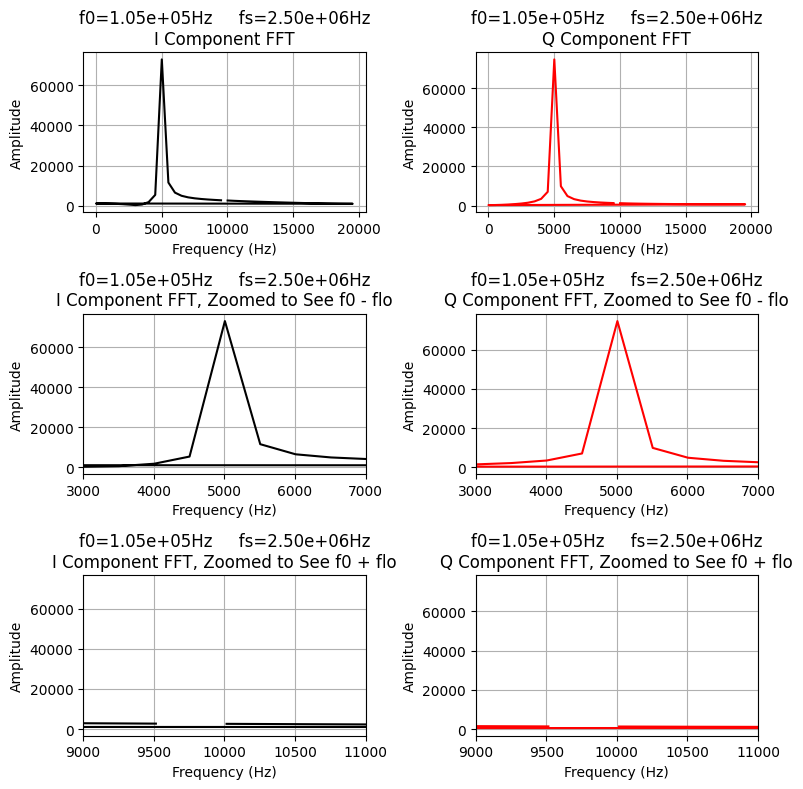

In [56]:
# Plot FFT's

I_X_decim = np.fft.rfft(I_x_decim)
I_X_shifted = np.fft.fftshift(I_X_decim)
Q_X_decim = np.fft.rfft(Q_x_decim)
Q_X_shifted = np.fft.fftshift(Q_X_decim)

freq = np.fft.rfftfreq(int(duration * (fs / R)), d=1/(fs/R))
freq_shifted = np.fft.fftshift(freq)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8,8))

axs[0,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[0,0].set_xlabel("Frequency (Hz)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT")
axs[0,0].grid()

axs[0,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[0,1].set_xlabel("Frequency (Hz)")
axs[0,1].set_ylabel("Amplitude")
axs[0,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT")
axs[0,1].grid()

axs[1,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[1,0].set_xlim(3_000, 7_000)
axs[1,0].set_xlabel("Frequency (Hz)")
axs[1,0].set_ylabel("Amplitude")
axs[1,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 - flo")
axs[1,0].grid()

axs[1,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[1,1].set_xlim(3_000, 7_000)
axs[1,1].set_xlabel("Frequency (Hz)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 - flo")
axs[1,1].grid()

axs[2,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[2,0].set_xlim(9_000, 11_000)
axs[2,0].set_xlabel("Frequency (Hz)")
axs[2,0].set_ylabel("Amplitude")
axs[2,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 + flo")
axs[2,0].grid()

axs[2,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[2,1].set_xlim(9_000, 11_000)
axs[2,1].set_xlabel("Frequency (Hz)")
axs[2,1].set_ylabel("Amplitude")
axs[2,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 + flo")
axs[2,1].grid()

plt.tight_layout()
plt.show()